In [1]:
import numpy as np

from game.enums import BoardType, Tribes, ActionTypes
from env.wrapper import EnvWrapper

In [2]:
BOARD_CONFIG_9x9 = {"board_size": (20,20), "board_type": BoardType.Dummy, "n_players": 2}
TRIBES = [Tribes.Omaji, Tribes.Yaddak]
N_GAMES = 5
MAX_DECISIONS = 200

In [3]:
def _make_env(seed=None):
    if seed is not None:
        np.random.seed(seed)
    env = EnvWrapper(BOARD_CONFIG_9x9, TRIBES)
    env.reset()
    return env


def _select_random_matrix_element(mat):
    nonzero_rows = np.where(mat.any(axis=1))[0]
    row_idx = np.random.choice(nonzero_rows)
    col_idx = np.random.choice(np.flatnonzero(mat[row_idx]))
    return int(row_idx), int(col_idx)


def _select_random_array_element(arr):
    return int(np.random.choice(np.flatnonzero(arr)))


def _random_action_from_mask(mask):
    """Build a valid random action list from a fresh action mask."""
    action_type = ActionTypes(int(np.random.choice(np.flatnonzero(mask[0]))))

    if action_type == ActionTypes.MoveUnit:
        unit_pos, tile_id = _select_random_matrix_element(mask[1])
        return [ActionTypes.MoveUnit.value, unit_pos, tile_id]

    elif action_type == ActionTypes.Attack:
        attacker_pos, defender_pos = _select_random_matrix_element(mask[2])
        return [ActionTypes.Attack.value, attacker_pos, defender_pos]

    elif action_type == ActionTypes.CreateUnit:
        city_idx, unit_type = _select_random_matrix_element(mask[3])
        return [ActionTypes.CreateUnit.value, city_idx, unit_type]

    elif action_type == ActionTypes.CaptureCity:
        unit_pos = _select_random_array_element(mask[4])
        return [ActionTypes.CaptureCity.value, unit_pos]

    elif action_type == ActionTypes.HealUnit:
        unit_pos = _select_random_array_element(mask[5])
        return [ActionTypes.HealUnit.value, unit_pos]

    elif action_type == ActionTypes.UpgradeCity:
        city_idx, choice = _select_random_matrix_element(mask[6])
        return [ActionTypes.UpgradeCity.value, city_idx, choice]

    elif action_type == ActionTypes.PlaceRoad:
        tile_id = _select_random_array_element(mask[7])
        return [ActionTypes.PlaceRoad.value, tile_id]

    elif action_type == ActionTypes.Upgrade2Vet:
        unit_pos = _select_random_array_element(mask[8])
        return [ActionTypes.Upgrade2Vet.value, unit_pos]
        

    else:  # EndTurn
        return [ActionTypes.EndTurn.value]

In [11]:
env = _make_env()
decision = 0

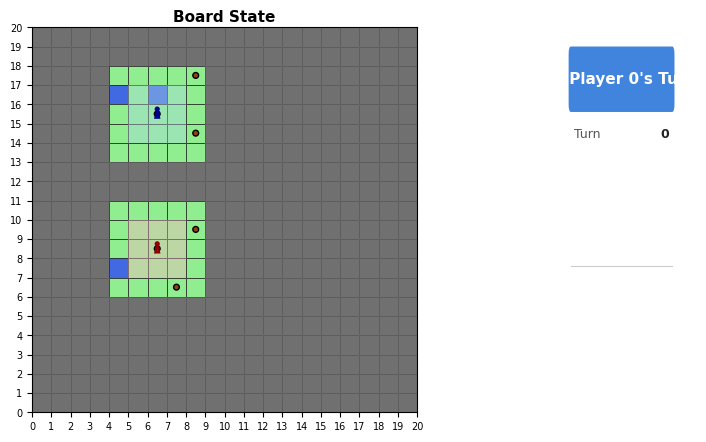

MoveUnit: 1.0 
Attack: 0.0 
CreateUnit: 0.0 
Capture: 0.0 
Heal: 0.0 
UpgradeCity: 1.0 
PlaceRoad: 1.0 
Upgrade2Vet: 0.0 
EndTurn: 1.0
{'log': {'action_type': <ActionTypes.MoveUnit: 0>, 'tiles_uncovered': 0}} 

Current player stars:  5 ( 1 )
Uncovered tiles:  25
Warrior (10.0/10.0) in state idle
-----------------------------------------------------------------------------------------
MoveUnit: 0.0 
Attack: 0.0 
CreateUnit: 1.0 
Capture: 0.0 
Heal: 0.0 
UpgradeCity: 1.0 
PlaceRoad: 1.0 
Upgrade2Vet: 0.0 
EndTurn: 1.0
{'log': {'action_type': <ActionTypes.CreateUnit: 2>, 'unit_type': <UnitType.Rider: 1>}} 

Current player stars:  2 ( 1 )
Uncovered tiles:  25
Warrior (10.0/10.0) in state idle
Rider (10.0/10.0) in state idle
-----------------------------------------------------------------------------------------
MoveUnit: 0.0 
Attack: 0.0 
CreateUnit: 0.0 
Capture: 0.0 
Heal: 0.0 
UpgradeCity: 0.0 
PlaceRoad: 0.0 
Upgrade2Vet: 0.0 
EndTurn: 1.0
{'log': {'action_type': <ActionTypes.EndTurn:

In [12]:
env.render()

while decision <= 512:
    mask = env.get_action_mask()
    action = _random_action_from_mask(mask)
    obs, reward, done, info = env.step(action)
    c_player = env.game.players[env.game.player_go_id]
    print("MoveUnit:",mask[0][0], "\nAttack:",mask[0][1],"\nCreateUnit:",mask[0][2],"\nCapture:",mask[0][3],"\nHeal:", mask[0][4],\
          "\nUpgradeCity:",mask[0][5],"\nPlaceRoad:",mask[0][6],"\nUpgrade2Vet:",mask[0][7],"\nEndTurn:",mask[0][-1])
    print(info, "\n")
    print("Current player stars: ",c_player.stars, "(", c_player.current_stars_per_turn,")")
    print("Uncovered tiles: ", len(c_player.uncovered_tile_ids))
    for unit in c_player.units_under_control.values():
        print(unit)

    print("-----------------------------------------------------------------------------------------")

    
    
    
    decision += 1
    if done:
        print("done")
        break

    
    

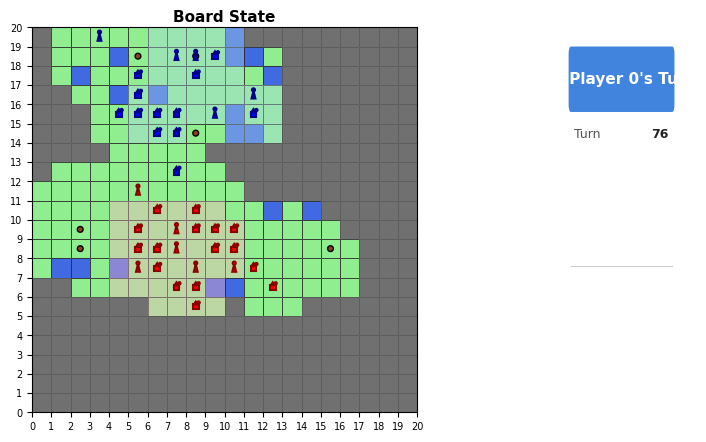

In [13]:
env.render()